In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

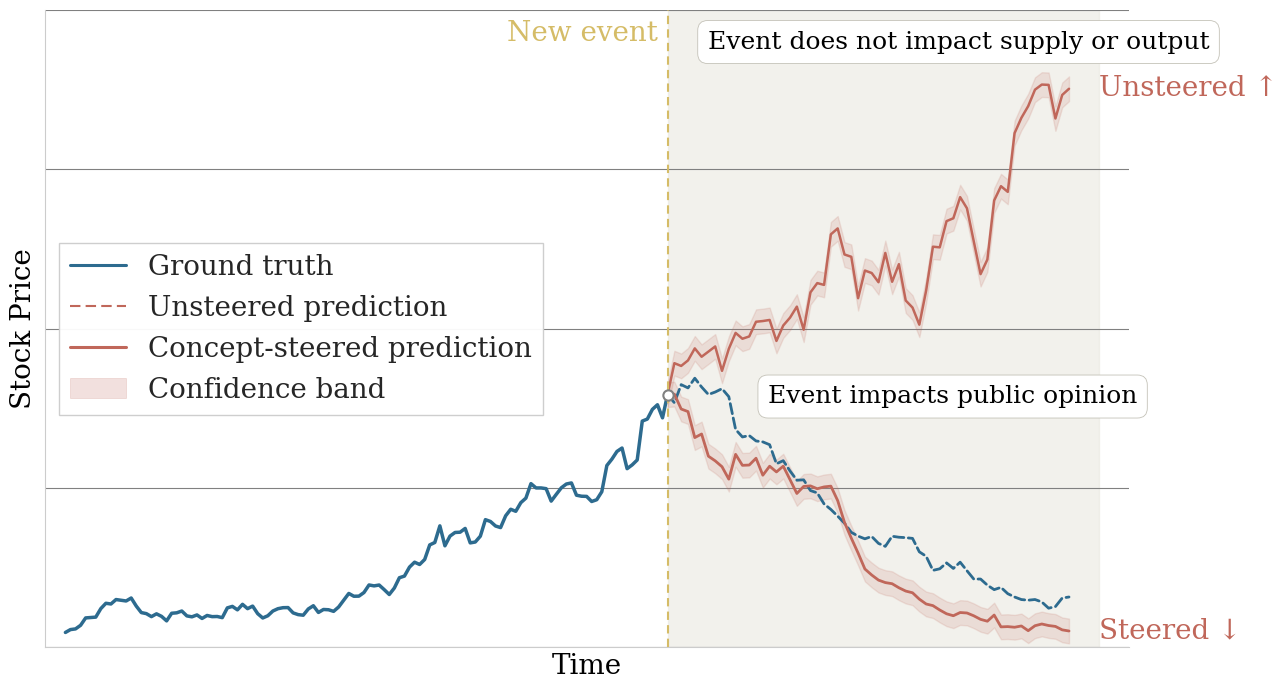

In [66]:
# ── Colors ────────────────────────────────────────────────────────────────────
BLUE      = "#2D6B8F"
CORAL     = "#C0675A"
AMBER     = "#D5BC67"
AXIS_COL  = "#C4C2B8"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'

fontsize = 20

# ── Helpers ───────────────────────────────────────────────────────────────────
def random_walk(start, n, drift, vol, seed):
    """Geometric random walk anchored exactly at `start` for t=0."""
    np.random.seed(seed)
    returns = drift + vol * np.random.randn(n)
    log_rel = np.r_[0, np.cumsum(returns[:-1])]
    return start * np.exp(log_rel)

def smooth_band(center_drift, start, n, spread_per_step):
    """Growing confidence band centered on smooth drift curve."""
    smooth  = start * np.exp(np.linspace(0, center_drift * n, n))
    half_w  = np.linspace(0, spread_per_step * n, n)
    return smooth + half_w, smooth - half_w

# ── Data ──────────────────────────────────────────────────────────────────────
n_hist     = 120
hist_x     = np.linspace(0, 30, n_hist)
hist_price = random_walk(start=50, n=n_hist, drift=0.018, vol=0.055, seed=42)
event_val  = hist_price[-1]   # price at event — anchor for all forecasts

event_x = 30                  # FIX: event_x is the time axis position, not the price

n_fore = 60
fore_x = np.linspace(30, 50, n_fore)

unsteered_y         = random_walk(event_val, n_fore, drift= 0.015, vol=0.05,  seed=7)
un_upper  = unsteered_y + 10
un_lower = unsteered_y - 10

steered_y           = random_walk(event_val, n_fore, drift=-0.020, vol=0.045, seed=12)
st_upper  = steered_y + 10
st_lower = steered_y - 10

gt_y = random_walk(event_val, n_fore, drift=-0.022, vol=0.04, seed=99)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")
ax.set_facecolor("white")
ax.set_xlim(-1, 53)

# FIX: ylim must match actual price scale, not hardcoded (2, 12)
ymin = min(st_lower.min(), hist_price.min()) * 0.92
ymax = max(un_upper.max(), hist_price.max()) * 1.10
ax.set_ylim(ymin, ymax)

# Forecast horizon shading
ax.axvspan(event_x, 51.5, color="#E8E6DE", alpha=0.55, zorder=0)

# Grid lines
for y in np.linspace(ymin, ymax, 5):
    ax.axhline(y, color="gray", linewidth=0.8, zorder=1)

# Confidence bands (both predictions)                  FIX: was only one band
ax.fill_between(fore_x, un_lower, un_upper, color=CORAL, alpha=0.15, zorder=2)
ax.fill_between(fore_x, st_lower, st_upper, color=CORAL, alpha=0.15, zorder=2)

# Historical line
ax.plot(hist_x, hist_price, color=BLUE, linewidth=2.5,
        solid_capstyle="round", solid_joinstyle="round", zorder=4, label="Historical price")

# Unsteered prediction
ax.plot(fore_x, unsteered_y, color=CORAL, linewidth=1.8,
        zorder=3, label="Unsteered ↑")

# Ground truth (blue dashed)
ax.plot(fore_x, gt_y, color=BLUE, linewidth=2,
        linestyle="dashed", dash_capstyle="round", zorder=4)

# Concept-steered prediction
ax.plot(fore_x, steered_y, color=CORAL, linewidth=2,
        solid_capstyle="round", solid_joinstyle="round", zorder=4, label="Steered ↓")

# World event line                                      FIX: was event_val (price), should be event_x (time)
ax.axvline(event_x, color=AMBER, linewidth=1.5, linestyle=(0, (4, 2.5)), zorder=5)

# Divergence point                                      FIX: was scatter at (event_val, 8.5) — both wrong
ax.scatter([event_x], [event_val], s=55, color="white",
           edgecolors="gray", linewidths=1.5, zorder=6)

# ── Labels ────────────────────────────────────────────────────────────────────
# World event label                                     FIX: was event_val, and y=12 (out of scale)
ax.text(event_x - 0.5, ymax * 0.985, "New event",
        ha="right", va="top", fontsize=fontsize, color=AMBER)

ax.text(51.5, unsteered_y[-1], "Unsteered ↑",
        ha="left", va="center", fontsize=fontsize, color=CORAL)
ax.text(51.5, steered_y[-1],   "Steered ↓",
        ha="left", va="center", fontsize=fontsize, color=CORAL)

# Annotation boxes                                      FIX: y coords scaled to actual data range
ax.annotate("Event does not impact supply or output",
            xy=(32, ymax * 0.97), fontsize=fontsize - 2,
            color="black", va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=AXIS_COL, lw=0.6))

ax.annotate("Event impacts public opinion",
            xy=(35, 250), fontsize=fontsize - 2,
            color="black", va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=AXIS_COL, lw=0.6))

ax.set_ylabel("Stock Price", fontsize=fontsize, color="black", labelpad=6)
ax.set_xlabel("Time",        fontsize=fontsize, color="black", labelpad=4)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.8)

ax.tick_params(colors="black", labelsize=9)
ax.set_xticks([])
ax.set_yticks([])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0], [0], color=BLUE,  linewidth=2.2, label="Ground truth"),
    plt.Line2D([0], [0], color=CORAL, linewidth=1.5, linestyle=(0,(5,2.5)), label="Unsteered prediction"),
    plt.Line2D([0], [0], color=CORAL, linewidth=2.2, label="Concept-steered prediction"),
    mpatches.Patch(facecolor=CORAL, alpha=0.2, edgecolor=CORAL, linewidth=0.6, label="Confidence band"),
]
ax.legend(handles=legend_elements, loc="center left",
          fontsize=fontsize, frameon=True, framealpha=0.95, fancybox=False)

plt.tight_layout()
